In [7]:
import os

import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile as wavfile
from scipy.stats import pearsonr
from sklearn.model_selection import KFold
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

import reconstructWave as rW
import MelFilterBank as mel

In [3]:
def createAudio(spectrogram, audiosr=16000, winLength=0.05, frameshift=0.01):
    """
    Create a reconstructed audio wavefrom
    
    Parameters
    ----------
    spectrogram: array
        Spectrogram of the audio
    sr: int
        Sampling rate of the audio
    windowLength: float
        Length of window (in seconds) in which spectrogram was calculated
    frameshift: float
        Shift (in seconds) after which next window was extracted
    Returns
    ----------
    scaled: array
        Scaled audio waveform
    """
    mfb = mel.MelFilterBank(int((audiosr*winLength)/2+1), spectrogram.shape[1], audiosr)
    nfolds = 10
    hop = int(spectrogram.shape[0]/nfolds)
    rec_audio = np.array([])
    for_reconstruction = mfb.fromLogMels(spectrogram)
    for w in range(0,spectrogram.shape[0],hop):
        spec = for_reconstruction[w:min(w+hop,for_reconstruction.shape[0]),:]
        rec = rW.reconstructWavFromSpectrogram(spec,spec.shape[0]*spec.shape[1],fftsize=int(audiosr*winLength),overlap=int(winLength/frameshift))
        rec_audio = np.append(rec_audio,rec)
    scaled = np.int16(rec_audio/np.max(np.abs(rec_audio)) * 32767)
    return scaled

In [4]:
feat_path = r'./features'
result_path = r'./results'
pts = ['sub-%02d'%i for i in range(1,11)]

winLength = 0.05
frameshift = 0.01
audiosr = 16000

nfolds = 10
kf = KFold(nfolds,shuffle=False)
est = LinearRegression(n_jobs=5)
pca = PCA()
numComps = 50

#Initialize empty matrices for correlation results, randomized contols and amount of explained variance
allRes = np.zeros((len(pts),nfolds,23))

for pNr, pt in enumerate(pts):
    #Load the data
    spectrogram = np.load(os.path.join(feat_path,f'{pt}_spec.npy'))
    data = np.load(os.path.join(feat_path,f'{pt}_feat.npy'))
    labels = np.load(os.path.join(feat_path,f'{pt}_procWords.npy'))
    featName = np.load(os.path.join(feat_path,f'{pt}_feat_names.npy'))

    #Initialize an empty spectrogram to save the reconstruction to
    rec_spec = np.zeros(spectrogram.shape)
    #Save the correlation coefficients for each fold
    rs = np.zeros((nfolds,spectrogram.shape[1]))
    for k,(train, test) in enumerate(kf.split(data)):
        #Z-Normalize with mean and std from the training data
        mu=np.mean(data[train,:],axis=0)
        std=np.std(data[train,:],axis=0)
        trainData=(data[train,:]-mu)/std
        testData=(data[test,:]-mu)/std

        #Fit PCA to training data
        pca.fit(trainData)

        #Tranform data into component space
        trainData=np.dot(trainData, pca.components_[:numComps,:].T)
        testData = np.dot(testData, pca.components_[:numComps,:].T)

        #Fit the regression model
        est.fit(trainData, spectrogram[train, :])
        #Predict the reconstructed spectrogram for the test data
        rec_spec[test, :] = est.predict(testData)

        #Evaluate reconstruction of this fold
        for specBin in range(spectrogram.shape[1]):
            if np.any(np.isnan(rec_spec)):
                print('%s has %d broken samples in reconstruction' % (pt, np.sum(np.isnan(rec_spec))))
            r, p = pearsonr(spectrogram[test, specBin], rec_spec[test, specBin])
            rs[k,specBin] = r

    #Show evaluation result
    print('%s has mean correlation of %f' % (pt, np.mean(rs)))
    allRes[pNr,:,:]=rs


    #Save reconstructed spectrogram
    os.makedirs(os.path.join(result_path), exist_ok=True)
    np.save(os.path.join(result_path,f'{pt}_predicted_spec.npy'), rec_spec)

    ##Synthesize waveform from spectrogram using Griffin-Lim
    #reconstructedWav = createAudio(rec_spec,audiosr=audiosr,winLength=winLength,frameshift=frameshift)
    #wavfile.write(os.path.join(result_path,f'{pt}_predicted.wav'),int(audiosr),reconstructedWav)

    ##For comparison synthesize the original spectrogram with Griffin-Lim
    #origWav = createAudio(spectrogram,audiosr=audiosr,winLength=winLength,frameshift=frameshift)
    #wavfile.write(os.path.join(result_path,f'{pt}_orig_synthesized.wav'),int(audiosr),origWav)

#Save results in numpy arrays          
np.save(os.path.join(result_path,'linearResults.npy'),allRes)

sub-01 has mean correlation of 0.303246
sub-02 has mean correlation of 0.424849
sub-03 has mean correlation of 0.697004
sub-04 has mean correlation of 0.588964
sub-05 has mean correlation of 0.381920
sub-06 has mean correlation of 0.783432
sub-07 has mean correlation of 0.507414
sub-08 has mean correlation of 0.468982
sub-09 has mean correlation of 0.473207
sub-10 has mean correlation of 0.536319


# Results

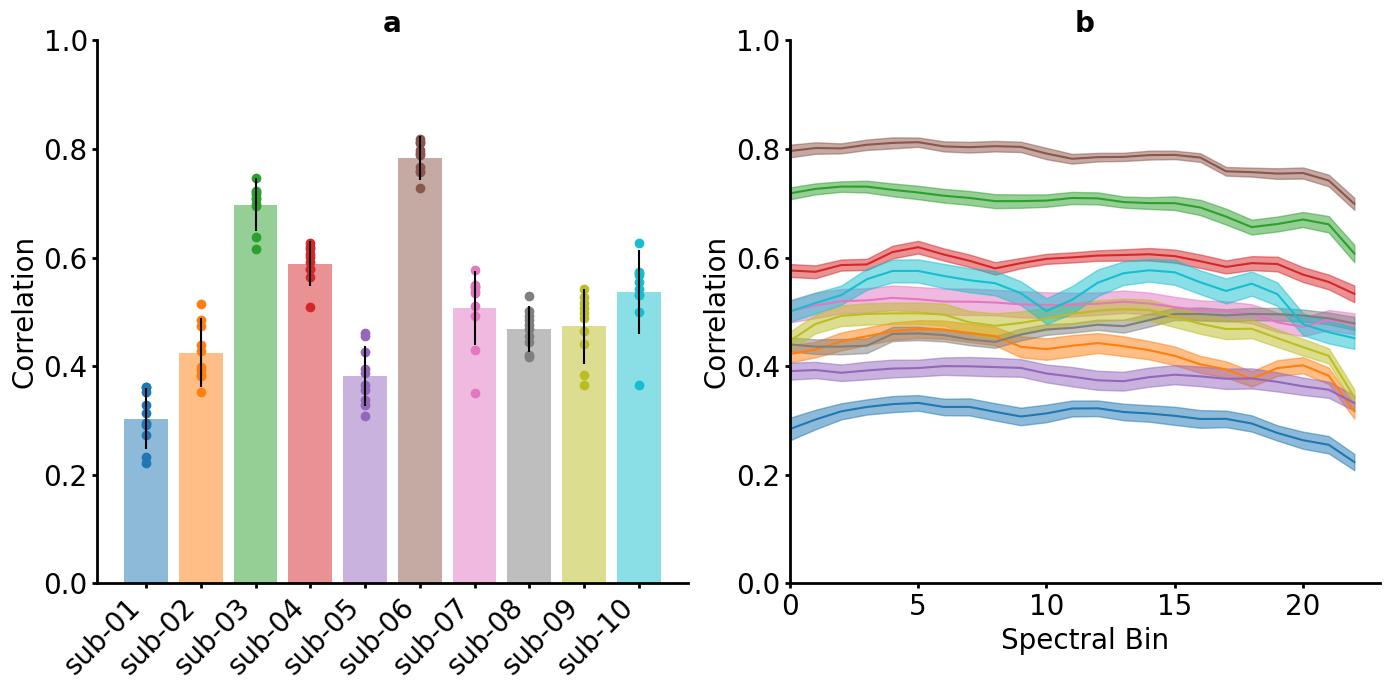

In [8]:
colors = ['C' + str(i) for i in range(10)]

meanCorrs = np.mean(allRes,axis=(1,2))
stdCorrs = np.std(allRes, axis=(1,2))

x = range(len(meanCorrs))
fig, ax = plt.subplots(1,2,figsize=(14,7))
#Barplot of average results
ax[0].bar(x,meanCorrs,yerr=stdCorrs,alpha=0.5,color=colors)
for p in range(allRes.shape[0]):
    #Add mean results of each patient as scatter points
    ax[0].scatter(np.zeros(allRes[p,:,:].shape[0])+p,np.mean(allRes[p,:,:],axis=1),color=colors[p])

ax[0].set_xticks(x)
ax[0].set_xticklabels(['sub-' + "{:02d}".format(i+1) for i in x],rotation=45, ha='right',fontsize=20)
ax[0].set_ylim(0,1)
ax[0].set_ylabel('Correlation')
#Title
ax[0].set_title('a',fontsize=20,fontweight="bold")
# Make pretty
plt.setp(ax[0].spines.values(), linewidth=2)
#The ticks
ax[0].xaxis.set_tick_params(width=2)
ax[0].yaxis.set_tick_params(width=2)
ax[0].xaxis.label.set_fontsize(20)
ax[0].yaxis.label.set_fontsize(20)
c = [a.set_fontsize(20) for a in ax[0].get_yticklabels()]

#Despine
ax[0].spines['right'].set_visible(False)
ax[0].spines['top'].set_visible(False)

#Mean across folds over spectral bins
specMean = np.mean(allRes,axis=1)
specStd = np.std(allRes,axis=1)
specBins = np.arange(allRes.shape[2])
for p in range(allRes.shape[0]):
    ax[1].plot(specBins, specMean[p,:],color=colors[p])
    error = specStd[p,:]/np.sqrt(allRes.shape[1])
    #Shaded areas highlight standard error
    ax[1].fill_between(specBins,specMean[p,:]-error,specMean[p,:]+error,alpha=0.5,color=colors[p])
ax[1].set_ylim(0,1)
ax[1].set_xlim(0,len(specBins))
ax[1].set_xlabel('Spectral Bin')
ax[1].set_ylabel('Correlation')
#Title
ax[1].set_title('b',fontsize=20,fontweight="bold")

#Make pretty
plt.setp(ax[1].spines.values(), linewidth=2)
#The ticks
ax[1].xaxis.set_tick_params(width=2)
ax[1].yaxis.set_tick_params(width=2)
ax[1].xaxis.label.set_fontsize(20)
ax[1].yaxis.label.set_fontsize(20)
c = [a.set_fontsize(20) for a in ax[1].get_yticklabels()]
c = [a.set_fontsize(20) for a in ax[1].get_xticklabels()]
#Despine
ax[1].spines['right'].set_visible(False)
ax[1].spines['top'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(result_path,'results.png'),dpi=600)
plt.show()

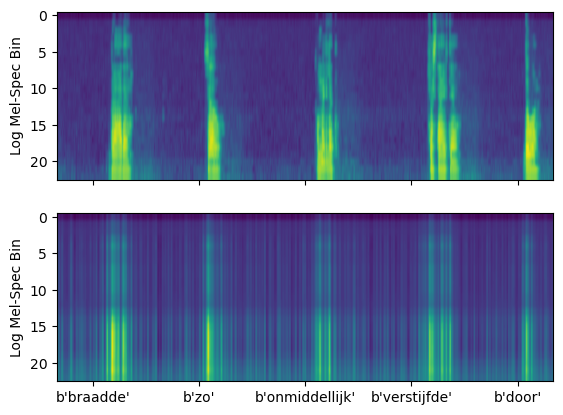

In [15]:
start_s = 5.5
stop_s=19.5

frameshift = 0.01
#Load prompted words
words = labels[int(start_s*(1/frameshift)):int(stop_s*(1/frameshift))]
words = [words[w] for w in np.arange(1,len(words)) if words[w]!=words[w-1] and words[w]!=b'']
cm='viridis'
fig, ax = plt.subplots(2, sharex=True)
#Plot spectrograms
pSta=int(start_s*(1/frameshift));pSto=int(stop_s*(1/frameshift))
ax[0].imshow(np.flipud(spectrogram[pSta:pSto, :].T), cmap=cm, interpolation=None,aspect='auto')
ax[0].set_ylabel('Log Mel-Spec Bin')
ax[1].imshow(np.flipud(rec_spec[pSta:pSto, :].T), cmap=cm, interpolation=None,aspect='auto')
plt.setp(ax[1], xticks=np.arange(0,pSto-pSta,int(1/frameshift)), xticklabels=[str(x/int(1/frameshift)) for x in np.arange(0,pSto-pSta,int(1/frameshift))])
plt.setp(ax[1], xticks=np.arange(int(1/frameshift),spectrogram[pSta:pSto, :].shape[0],3*int(1/frameshift)), xticklabels=words)
ax[1].set_ylabel('Log Mel-Spec Bin')
    
plt.show()